In [347]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [348]:
df = pd.read_csv('/content/drive/MyDrive/Internship/student_performance.csv')
display(df.head())

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [349]:
df.head(3)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [350]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql('students',conn,if_exists='replace',index=False)
cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]
print(f"Number of rows in the 'students' table: {count}")

Number of rows in the 'students' table: 30


In [351]:
cursor.execute("PRAGMA table_info(students)")
columns = cursor.fetchall()
for column in columns:
    print(column[1],column[2])

student_id INTEGER
name TEXT
age INTEGER
gender TEXT
department TEXT
semester INTEGER
math_score INTEGER
science_score INTEGER
english_score INTEGER
programming_score INTEGER
attendance_percentage INTEGER
city TEXT
admission_year INTEGER


In [352]:
def run_query(sql, description=""):
  if description:
    print(f"\n")
    print(f"{description}")

  result = pd.read_sql_query(sql, conn)
  print(f"")
  return result


In [353]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"\n{'='*55}")
  result = pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

In [354]:
query1 = """SELECT student_id,name,department,math_score,attendance_percentage FROM students ORDER BY math_score DESC LIMIT 5; """
result1 = run_query(query1,"")

 student_id           name       department  math_score  attendance_percentage
       1010     Ananya Das Computer Science          95                     98
       1022    Tanvi Mehta Computer Science          93                     97
       1005     Arjun Nair Computer Science          92                     90
       1030 Akanksha Yadav Computer Science          91                     95
       1018 Swati Kulkarni Computer Science          90                     94


In [355]:
query2 = """SELECT student_id,name,department,math_score,attendance_percentage FROM students ORDER BY student_id DESC LIMIT 5; """
result1 = run_query(query2,"Query2:Last 5 Students (LIMIT + ORDER BY) ")


Query2:Last 5 Students (LIMIT + ORDER BY) 

 student_id           name       department  math_score  attendance_percentage
       1030 Akanksha Yadav Computer Science          91                     95
       1029     Nitin Jain       Mechanical          75                     84
       1028  Sunita Pillai            Civil          60                     73
       1027  Gaurav Shukla Computer Science          84                     87
       1026     Rekha Nair      Electronics          72                     82


In [356]:
query2 = """SELECT name,department,math_score FROM students ORDER BY math_score DESC LIMIT 5; """
result1 = run_query(query2,"Query2:Last 5 Students (LIMIT + ORDER BY) ")


Query2:Last 5 Students (LIMIT + ORDER BY) 

          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [357]:
query2 = """SELECT name,department,programming_score FROM students ORDER BY programming_score ASC LIMIT 5; """
result1 = run_query(query2,"Query2:Last 5 Students (LIMIT + ORDER BY) ")


Query2:Last 5 Students (LIMIT + ORDER BY) 

         name department  programming_score
 Manoj Pandey      Civil                 38
Sunita Pillai      Civil                 39
  Kiran Kumar      Civil                 40
 Sanjay Dubey      Civil                 42
  Pooja Gupta      Civil                 44


In [358]:
query2 = """SELECT name,department,programming_score FROM students WHERE programming_score BETWEEN 50 AND 75 ORDER BY programming_score DESC LIMIT 5; """
result1 = run_query(query2,"Query: Students with Programming Score Between 50 and 75")


Query: Students with Programming Score Between 50 and 75

         name  department  programming_score
  Vikram Iyer Electronics                 72
 Ritu Agarwal Electronics                 69
   Rekha Nair Electronics                 63
Harish Pillai Electronics                 58
  Rohit Verma Electronics                 55


In [359]:
query2 = """SELECT name,math_score,science_score,programming_score,attendance_percentage FROM students WHERE department = 'Computer Science' ORDER BY programming_score DESC; """
result1 = run_query(query2,"Query2:Last 5 Students (LIMIT + ORDER BY) ")


Query2:Last 5 Students (LIMIT + ORDER BY) 

          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79     

In [360]:
query_departments = """SELECT DISTINCT department FROM students;"""
run_query(query_departments, "Query: All Departments")


Query: All Departments

      department
Computer Science
     Electronics
      Mechanical
           Civil


,department
0,Computer Science
1,Electronics
2,Mechanical
3,Civil


In [361]:
query_overall_top_student = """SELECT name,department, programming_score FROM students ORDER BY programming_score DESC LIMIT 1; """
run_query(query_overall_top_student, "Query: Overall Top Student in Programming")


Query: Overall Top Student in Programming

      name       department  programming_score
Ananya Das Computer Science                 97


,name,department,programming_score
0,Ananya Das,Computer Science,97


In [362]:
query2 = """SELECT name,department,attendance_percentage FROM students WHERE attendance_percentage > 90 AND department <> 'Civil' ; """
result1 = run_query(query2,"Query2:Last 5 Students (LIMIT + ORDER BY) ")


Query2:Last 5 Students (LIMIT + ORDER BY) 

          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
   Sneha Reddy       Mechanical                     95
   Divya Singh Computer Science                     96
    Ananya Das Computer Science                     98
 Kavya Nambiar       Mechanical                     91
  Ritu Agarwal      Electronics                     93
Swati Kulkarni Computer Science                     94
   Tanvi Mehta Computer Science                     97
     Amit Bose Computer Science                     91
Akanksha Yadav Computer Science                     95


In [363]:
query2 = """SELECT name,department,attendance_percentage FROM students WHERE attendance_percentage NOT BETWEEN 0 AND 85 ; """
result1 = run_query(query2,"Query2: Students with attendance NOT BETWEEN 0 and 85")


Query2: Students with attendance NOT BETWEEN 0 and 85

          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
   Priya Patel Computer Science                     87
   Sneha Reddy       Mechanical                     95
    Arjun Nair Computer Science                     90
   Divya Singh Computer Science                     96
    Ananya Das Computer Science                     98
    Suresh Rao Computer Science                     88
 Kavya Nambiar       Mechanical                     91
  Ritu Agarwal      Electronics                     93
Swati Kulkarni Computer Science                     94
  Nisha Kapoor Computer Science                     89
   Tanvi Mehta Computer Science                     97
 Preeti Saxena       Mechanical                     86
     Amit Bose Computer Science                     91
 Gaurav Shukla Computer Science                     87
Akanksha Yadav Computer Science                     95


In [364]:
dept_data ={

'dept_code':['CS', 'EC', 'ME', 'CE'],

'dept_name':['Computer Science', 'Electronics', 'Mechanical', 'Civil'],

'hod_name': ['Dr. Sharma', 'Dr. Reddy', 'Dr. Patel', 'Dr. Kumar'],

'established':[1985, 1988, 1972, 1965],

'intake': [60, 60, 60, 60]

}

dept_df = pd.DataFrame(dept_data)


dept_map= {

'Computer Science': 'CS',

'Electronics': 'EC',

'Mechanical': 'ME',

'Civil': 'CE'

}

df['dept_code'] = df['department'].map(dept_map)

df.to_sql('students', conn, if_exists='replace', index=False)

dept_df.to_sql('departments', conn, if_exists='replace', index=False)
print(dept_df)

  dept_code         dept_name    hod_name  established  intake
0        CS  Computer Science  Dr. Sharma         1985      60
1        EC       Electronics   Dr. Reddy         1988      60
2        ME        Mechanical   Dr. Patel         1972      60
3        CE             Civil   Dr. Kumar         1965      60


In [365]:
query_join="""SELECT s.name,s.math_score,d.dept_name,d.hod_name,d.established FROM students s INNER JOIN departments d ON s.dept_code = d.dept_code ORDER BY s.math_score DESC LIMIT 8;"""

run_query(query_join,"Query: Joining Students and Departments")



Query: Joining Students and Departments

          name  math_score        dept_name   hod_name  established
    Ananya Das          95 Computer Science Dr. Sharma         1985
   Tanvi Mehta          93 Computer Science Dr. Sharma         1985
    Arjun Nair          92 Computer Science Dr. Sharma         1985
Akanksha Yadav          91 Computer Science Dr. Sharma         1985
Swati Kulkarni          90 Computer Science Dr. Sharma         1985
   Divya Singh          88 Computer Science Dr. Sharma         1985
  Ritu Agarwal          87      Electronics  Dr. Reddy         1988
     Amit Bose          86 Computer Science Dr. Sharma         1985


,name,math_score,dept_name,hod_name,established
0,Ananya Das,95,Computer Science,Dr. Sharma,1985
1,Tanvi Mehta,93,Computer Science,Dr. Sharma,1985
2,Arjun Nair,92,Computer Science,Dr. Sharma,1985
3,Akanksha Yadav,91,Computer Science,Dr. Sharma,1985
4,Swati Kulkarni,90,Computer Science,Dr. Sharma,1985
5,Divya Singh,88,Computer Science,Dr. Sharma,1985
6,Ritu Agarwal,87,Electronics,Dr. Reddy,1988
7,Amit Bose,86,Computer Science,Dr. Sharma,1985


In [366]:
query_join="""SELECT s.name,s.math_score,d.dept_name,d.hod_name,d.established FROM students s JOIN departments d ON s.dept_code = d.dept_code ORDER BY s.math_score DESC LIMIT 8;"""

run_query(query_join,"Query: Joining Students and Departments")



Query: Joining Students and Departments

          name  math_score        dept_name   hod_name  established
    Ananya Das          95 Computer Science Dr. Sharma         1985
   Tanvi Mehta          93 Computer Science Dr. Sharma         1985
    Arjun Nair          92 Computer Science Dr. Sharma         1985
Akanksha Yadav          91 Computer Science Dr. Sharma         1985
Swati Kulkarni          90 Computer Science Dr. Sharma         1985
   Divya Singh          88 Computer Science Dr. Sharma         1985
  Ritu Agarwal          87      Electronics  Dr. Reddy         1988
     Amit Bose          86 Computer Science Dr. Sharma         1985


,name,math_score,dept_name,hod_name,established
0,Ananya Das,95,Computer Science,Dr. Sharma,1985
1,Tanvi Mehta,93,Computer Science,Dr. Sharma,1985
2,Arjun Nair,92,Computer Science,Dr. Sharma,1985
3,Akanksha Yadav,91,Computer Science,Dr. Sharma,1985
4,Swati Kulkarni,90,Computer Science,Dr. Sharma,1985
5,Divya Singh,88,Computer Science,Dr. Sharma,1985
6,Ritu Agarwal,87,Electronics,Dr. Reddy,1988
7,Amit Bose,86,Computer Science,Dr. Sharma,1985


In [367]:
query_join="""SELECT s.name,s.programming_score,d.dept_name,d.hod_name,d.established FROM students s LEFT JOIN departments d ON s.dept_code = d.dept_code ORDER BY s.programming_score DESC LIMIT 8;"""

run_query(query_join,"Query: Joining Students and Departments")



Query: Joining Students and Departments

          name  programming_score        dept_name   hod_name  established
    Ananya Das                 97 Computer Science Dr. Sharma         1985
   Tanvi Mehta                 96 Computer Science Dr. Sharma         1985
    Arjun Nair                 95 Computer Science Dr. Sharma         1985
Akanksha Yadav                 94 Computer Science Dr. Sharma         1985
   Divya Singh                 93 Computer Science Dr. Sharma         1985
Swati Kulkarni                 92 Computer Science Dr. Sharma         1985
  Aarav Sharma                 91 Computer Science Dr. Sharma         1985
     Amit Bose                 89 Computer Science Dr. Sharma         1985


,name,programming_score,dept_name,hod_name,established
0,Ananya Das,97,Computer Science,Dr. Sharma,1985
1,Tanvi Mehta,96,Computer Science,Dr. Sharma,1985
2,Arjun Nair,95,Computer Science,Dr. Sharma,1985
3,Akanksha Yadav,94,Computer Science,Dr. Sharma,1985
4,Divya Singh,93,Computer Science,Dr. Sharma,1985
5,Swati Kulkarni,92,Computer Science,Dr. Sharma,1985
6,Aarav Sharma,91,Computer Science,Dr. Sharma,1985
7,Amit Bose,89,Computer Science,Dr. Sharma,1985


In [368]:
query_join="""SELECT s.name,s.science_score,d.dept_name,d.hod_name,d.established FROM departments d LEFT JOIN students s ON s.dept_code = d.dept_code ORDER BY s.science_score DESC LIMIT 8;"""

run_query(query_join,"Query: Emulating RIGHT JOIN with LEFT JOIN")


Query: Emulating RIGHT JOIN with LEFT JOIN

          name  science_score        dept_name   hod_name  established
Akanksha Yadav             93 Computer Science Dr. Sharma         1985
   Divya Singh             91 Computer Science Dr. Sharma         1985
   Tanvi Mehta             90 Computer Science Dr. Sharma         1985
    Ananya Das             89 Computer Science Dr. Sharma         1985
    Arjun Nair             88 Computer Science Dr. Sharma         1985
Swati Kulkarni             87 Computer Science Dr. Sharma         1985
    Suresh Rao             86 Computer Science Dr. Sharma         1985
  Nisha Kapoor             84 Computer Science Dr. Sharma         1985


,name,science_score,dept_name,hod_name,established
0,Akanksha Yadav,93,Computer Science,Dr. Sharma,1985
1,Divya Singh,91,Computer Science,Dr. Sharma,1985
2,Tanvi Mehta,90,Computer Science,Dr. Sharma,1985
3,Ananya Das,89,Computer Science,Dr. Sharma,1985
4,Arjun Nair,88,Computer Science,Dr. Sharma,1985
5,Swati Kulkarni,87,Computer Science,Dr. Sharma,1985
6,Suresh Rao,86,Computer Science,Dr. Sharma,1985
7,Nisha Kapoor,84,Computer Science,Dr. Sharma,1985


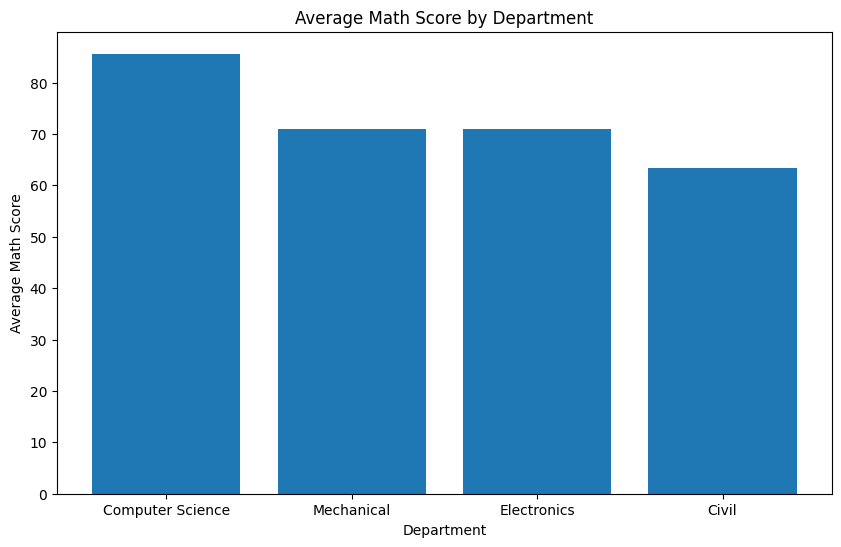

In [374]:
chart1_sql="""SELECT department, ROUND(AVG(math_score), 2) AS avg_math FROM students GROUP BY department ORDER BY avg_math DESC"""
chart1_data = pd.read_sql_query(chart1_sql, conn)
fig,ax= plt.subplots(figsize=(10,6))
ax.bar(chart1_data['department'], chart1_data['avg_math'])
plt.title('Average Math Score by Department')
plt.xlabel('Department')
plt.ylabel('Average Math Score')
plt.show()


Query: Top Programming Scores by Gender and Department

gender       department  top_programming_score
Female            Civil                     44
  Male            Civil                     42
Female Computer Science                     97
  Male Computer Science                     95
Female      Electronics                     69
  Male      Electronics                     72
Female       Mechanical                     53
  Male       Mechanical                     50


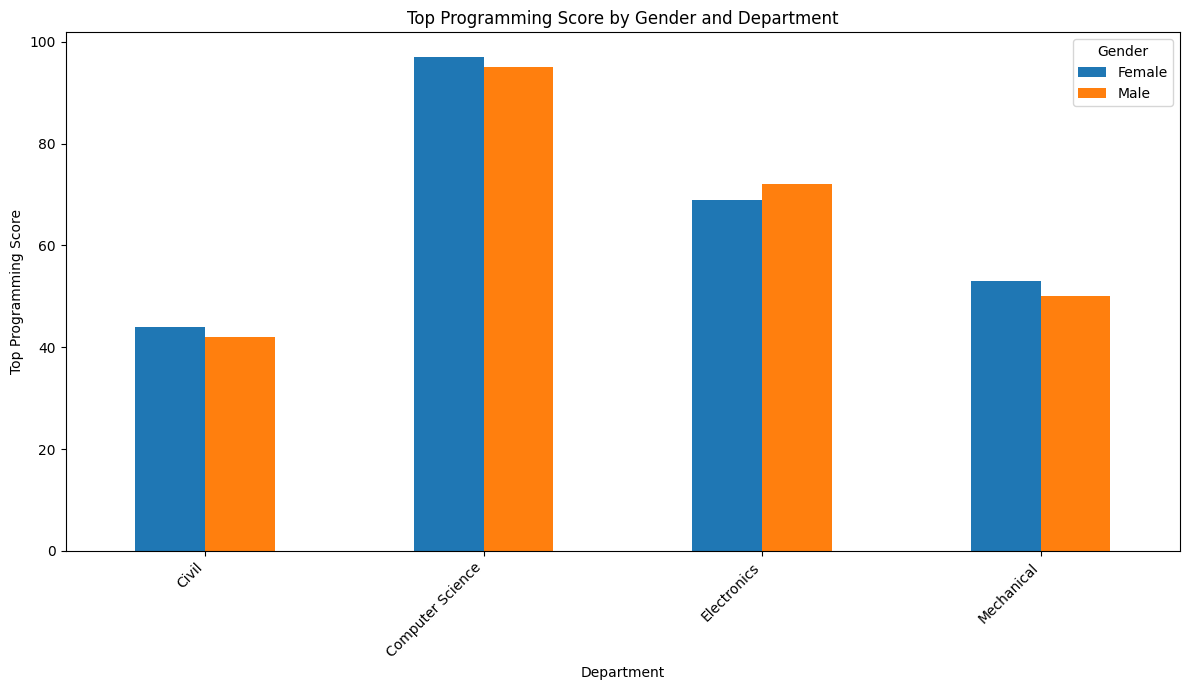

In [375]:
query_top_scores_gender_dept = """ SELECT gender, department, MAX(programming_score) AS top_programming_score FROM students GROUP BY gender, department ORDER BY department, gender; """

top_scores_gender_dept_df = run_query(query_top_scores_gender_dept, "Query: Top Programming Scores by Gender and Department")


pivot_df = top_scores_gender_dept_df.pivot_table(index='department', columns='gender', values='top_programming_score')

fig, ax = plt.subplots(figsize=(12, 7))
pivot_df.plot(kind='bar', ax=ax)

plt.title('Top Programming Score by Gender and Department')
plt.xlabel('Department')
plt.ylabel('Top Programming Score')
plt.xticks(rotation=45, ha="right")
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


Panel 1 Data: Avg Math by Department

      department  avg_math
Computer Science     85.62
      Mechanical     71.00
     Electronics     71.00
           Civil     63.40

Panel 2 Data: Student Count by Department

      department  student_count
Computer Science             13
      Mechanical              6
     Electronics              6
           Civil              5

Panel 3 Data: Top 8 Students by Total Score

          name  total_score
    Ananya Das          371
   Tanvi Mehta          367
Akanksha Yadav          365
    Arjun Nair          356
   Divya Singh          356
Swati Kulkarni          354
     Amit Bose          336
    Suresh Rao          334

Panel 4 Data: Gender-wise Average Attendance

gender  avg_attendance
Female           88.53
  Male           80.47


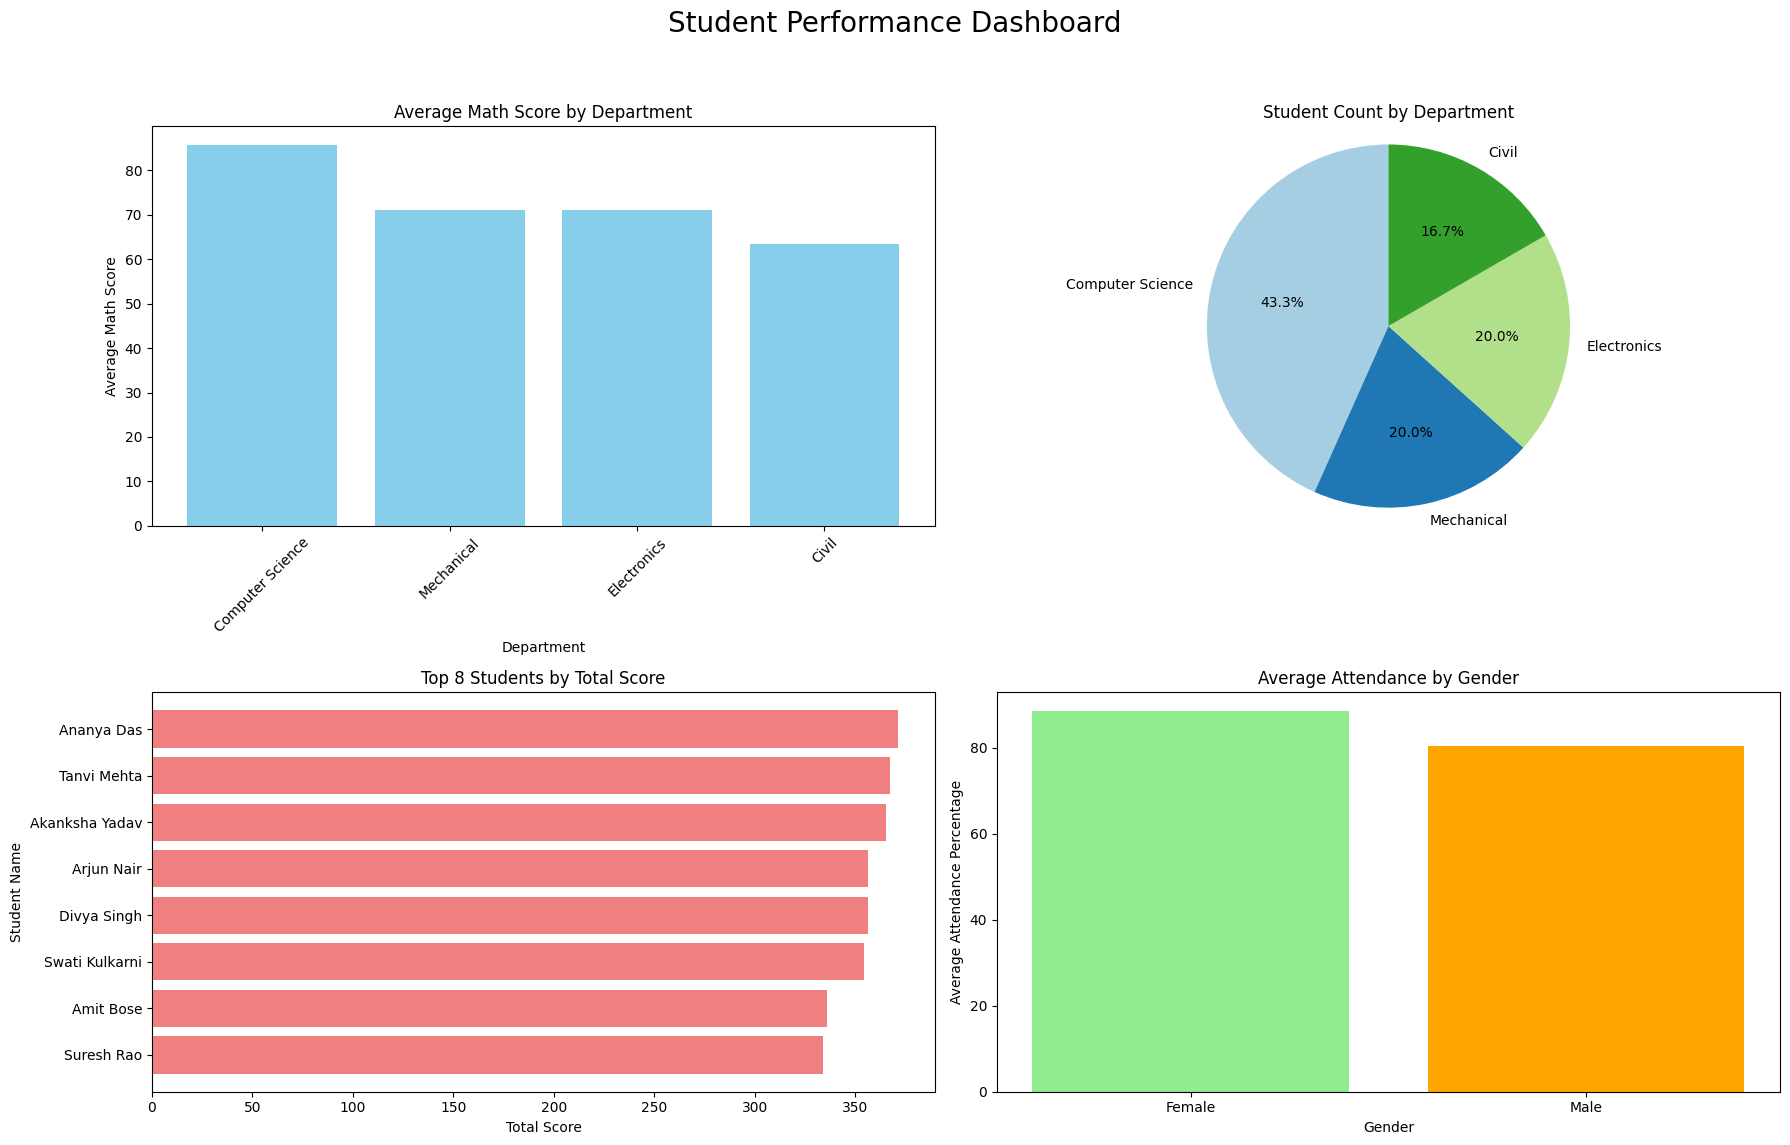

In [377]:
query_panel1 = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC;
"""
df_panel1 = run_query(query_panel1, "Panel 1 Data: Avg Math by Department")


query_panel2 = """
SELECT department, COUNT(student_id) AS student_count
FROM students
GROUP BY department
ORDER BY student_count DESC;
"""
df_panel2 = run_query(query_panel2, "Panel 2 Data: Student Count by Department")


query_panel3 = """
SELECT name, (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8;
"""
df_panel3 = run_query(query_panel3, "Panel 3 Data: Top 8 Students by Total Score")


query_panel4 = """
SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC;
"""
df_panel4 = run_query(query_panel4, "Panel 4 Data: Gender-wise Average Attendance")



fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Student Performance Dashboard', fontsize=20)


axes[0, 0].bar(df_panel1['department'], df_panel1['avg_math'], color='skyblue')
axes[0, 0].set_title('Average Math Score by Department')
axes[0, 0].set_xlabel('Department')
axes[0, 0].set_ylabel('Average Math Score')
axes[0, 0].tick_params(axis='x', rotation=45)


axes[0, 1].pie(df_panel2['student_count'], labels=df_panel2['department'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[0, 1].set_title('Student Count by Department')
axes[0, 1].axis('equal')

axes[1, 0].barh(df_panel3['name'], df_panel3['total_score'], color='lightcoral')
axes[1, 0].set_title('Top 8 Students by Total Score')
axes[1, 0].set_xlabel('Total Score')
axes[1, 0].set_ylabel('Student Name')
axes[1, 0].invert_yaxis()


axes[1, 1].bar(df_panel4['gender'], df_panel4['avg_attendance'], color=['lightgreen', 'orange'])
axes[1, 1].set_title('Average Attendance by Gender')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Average Attendance Percentage')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()